In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map(
    {
        0: iris.target_names[0], # 'setosa',
        1: iris.target_names[1], # 'versicolor',
        2: iris.target_names[2], # 'virginica'
    }
)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


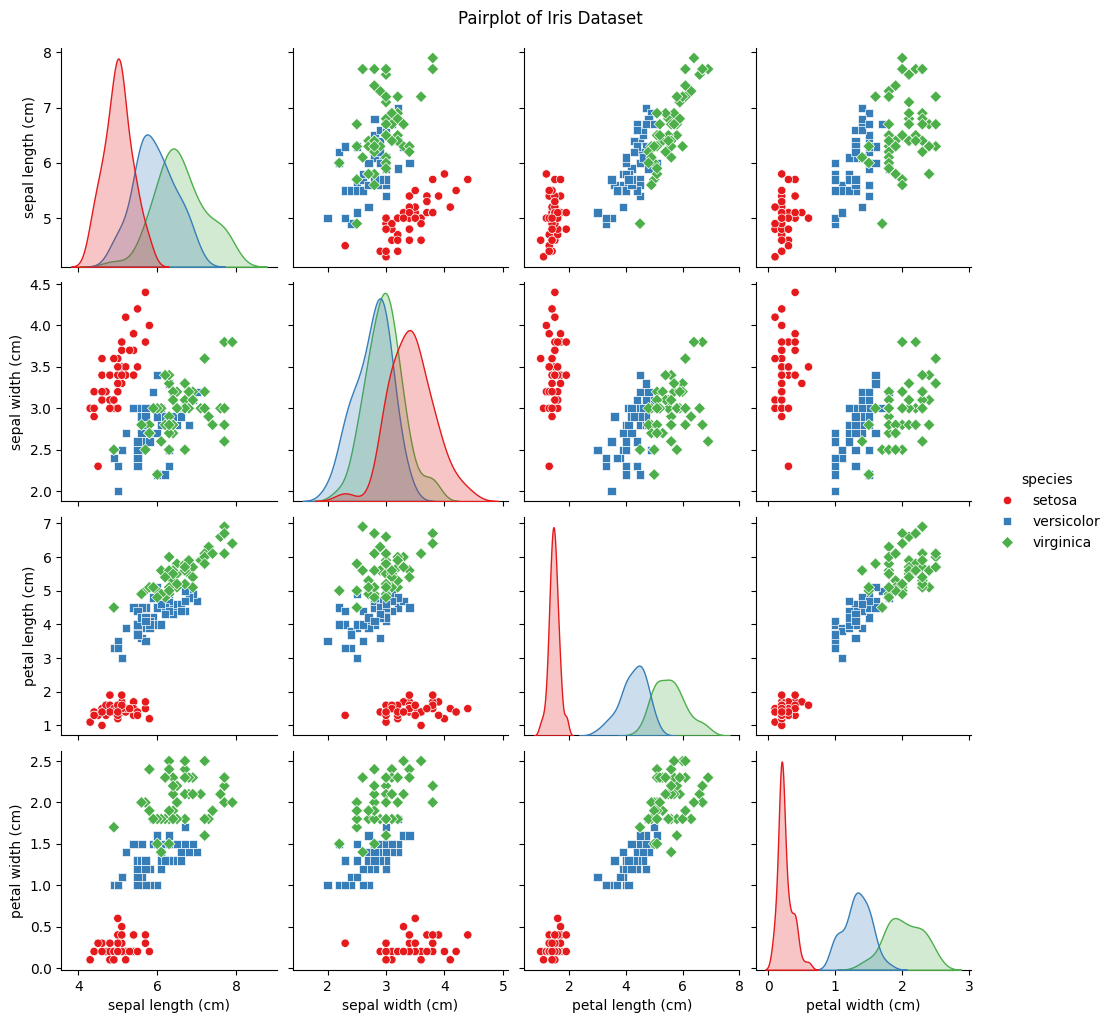

In [ ]:
sns.pairplot(df.drop('target', axis=1), hue='species', palette='Set1', markers=['o','s','D'])
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

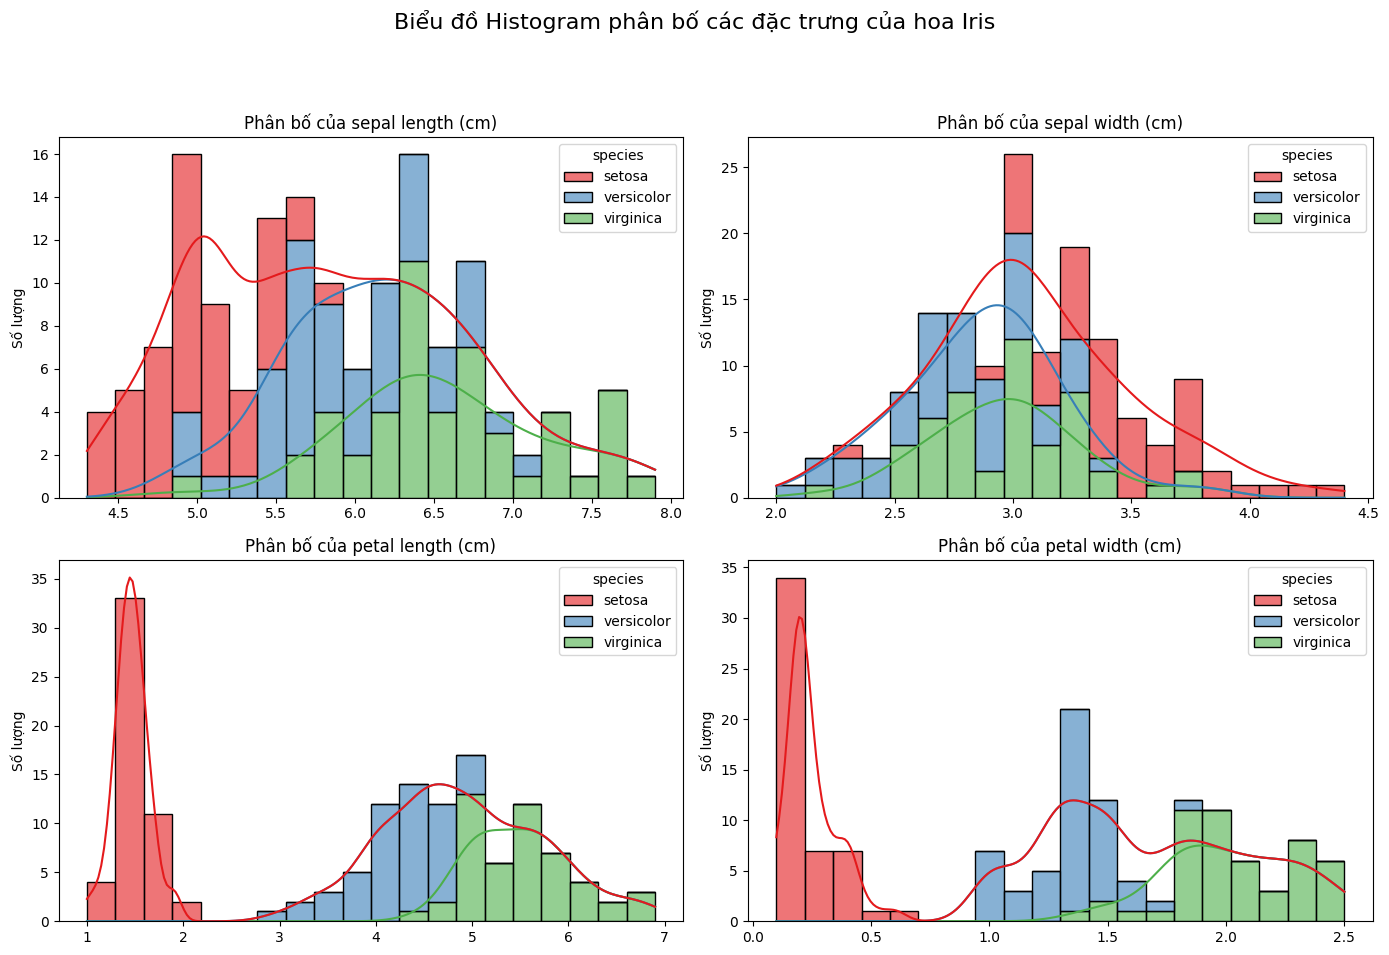

In [ ]:
# Thiết lập kích thước cho vùng vẽ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Biểu đồ Histogram phân bố các đặc trưng của hoa Iris', fontsize=16, y=0.95)

# Các cột đặc trưng cần vẽ histogram
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Vẽ histogram cho từng đặc trưng và phân biệt theo loài (species)
for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.histplot(data=df, x=col, hue='species', kde=True, bins=20, ax=ax, palette='Set1', multiple='stack', alpha=0.6)
    ax.set_title(f'Phân bố của {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

#khai báo X(đặc trưng) và y (nhãn)
X = df.drop(['target', 'species'], axis=1)
y = df['target']

#chia dữ liệu theo tỉ lệ 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Khởi tạo mô hình Naive Bayes
gnb = GaussianNB()

# Khởi tạo mô hình Naive Bayes
gnb.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = gnb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Đánh giá mô hình
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



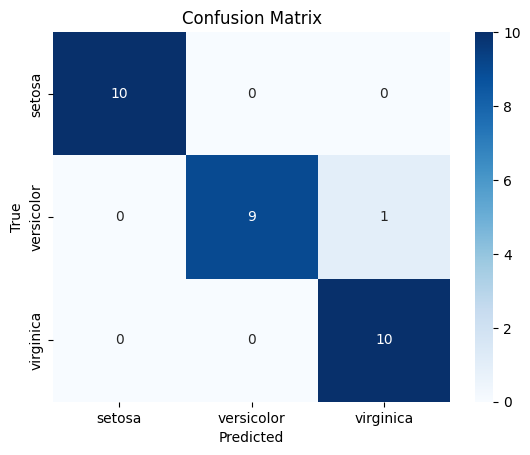

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
#Mẫu hoa mới :[sepal]
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = gnb.predict(sample)
print('Prediction:', iris.target_names[prediction])
probabilites = gnb.predict_proba(sample)
print('Probabilities:', probabilites)

for i, species_name in enumerate(iris.target_names):
    print(f'{species_name}: {probabilites[0][i]*100:.2f}%')

Prediction: ['setosa']
Probabilities: [[1.00000000e+00 1.63139388e-20 1.57464860e-25]]
setosa: 100.00%
versicolor: 0.00%
virginica: 0.00%


In [ ]:
!pip install -q streamlit

In [ ]:
!curl -L -A "/content/" \
-o setosa.jpg \
"https://upload.wikimedia.org/wikipedia/commons/1/11/Iris_setosa_2.jpg?utm_source=vi.wikipedia.org&utm_campaign=imageinfo&utm_content=original"
!curl -L -A "/content/" \
-o versicolor.jpg \
"https://upload.wikimedia.org/wikipedia/commons/2/27/Blue_Flag%2C_Ottawa.jpg?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original"
!curl -L -A "/content/" \
-o virginica.jpg \
"https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3545k  100 3545k    0     0  10.7M      0 --:--:-- --:--:-- --:--:-- 10.7M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  260k  100  260k    0     0  1636k      0 --:--:-- --:--:-- --:--:-- 1647k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2691k  100 2691k    0     0  10.4M      0 --:--:-- --:--:-- --:--:-- 10.4M


In [ ]:
import gradio as gr
species_name = {
    'setosa': "/content/setosa.jpg",
    'versicolor': "/content/versicolor.jpg",
    'virginica' : "/content/virginica.jpg"
}

In [ ]:
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    #đưa dữ liệu đầu vào thành numpy
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    #dự đoán lớp và xác suất
    prediction = gnb.predict(input_data)[0]
    probabilites = gnb.predict_proba(input_data)[0]

    species = iris.target_names[prediction]
    image = species_name[species]

    #tạo dictionary chứa xác suất 3 lớp
    prob_dict = {
        iris.target_names[i].capitalize(): float(probabilites[i])
        for i in range(len(iris.target_names))
    }
    return species, image, prob_dict

In [ ]:
with gr.Blocks(title="Iris Flower Classification") as demo:
    gr.Markdown("## Iris Flower Classification")

    with gr.Row():
        with gr.Column():
            sepal_length = gr.Slider(minimum=4, maximum=8, value=5.1, label="Sepal Length")
            sepal_width = gr.Slider(minimum=2, maximum=4.5,value=3.5, label="Sepal Width")
            petal_length = gr.Slider(minimum=1, maximum=7, value= 1.4, label="Petal Length")
            petal_width = gr.Slider(minimum=0.1, maximum=2.5, value=0.2, label="Petal Width")
            btn_predict = gr.Button("Predict")

        with gr.Column():
            species = gr.Textbox(label="Species")
            image = gr.Image(label="Image")
            probabilities = gr.Label(label="Probabilities")
    btn_predict.click(predict_iris, inputs=[sepal_length, sepal_width, petal_length, petal_width], outputs=[species, image, probabilities])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f576c3e0741f620653.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Demo bằng Streamlit (thay cho Gradio)
Dưới đây ghi toàn bộ ứng dụng ra file `app.py`, tách riêng 3 phần: huấn luyện, dự đoán, giao diện.

In [ ]:
%%writefile app.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

st.set_page_config(page_title="Demo Phân Loại Hoa Iris", page_icon="🌸", layout="wide")

# Đường dẫn ảnh minh họa cho từng loài (đã tải ở các bước trước)
IMAGES = {
    "setosa": "setosa.jpg",
    "versicolor": "versicolor.jpg",
    "virginica": "virginica.jpg",
}

# Cache: mô hình chỉ huấn luyện 1 lần, không train lại khi kéo slider
@st.cache_resource
def load_model():
    iris = load_iris()
    X, y = iris.data, iris.target
    # Mô hình dùng để demo: huấn luyện trên toàn bộ dữ liệu (giống bản Gradio)
    model = GaussianNB().fit(X, y)
    # Mô hình riêng chỉ để tính độ chính xác tham chiếu trên tập Test (80/20)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    acc = accuracy_score(y_te, GaussianNB().fit(X_tr, y_tr).predict(X_te))
    return iris, model, acc

iris, model, test_acc = load_model()

# dự đoán
def predict(model, sl, sw, pl, pw):
    """Nhận 4 số đo, trả về (mảng đầu vào, xác suất 3 loài)."""
    x_new = np.array([[sl, sw, pl, pw]])
    return x_new[0], model.predict_proba(x_new)[0]

# Sidebar (Bonus)
with st.sidebar:
    st.header("Thông tin mô hình")
    st.write("**Mô hình:** Gaussian Naive Bayes")
    st.write("**Dữ liệu:** Iris (150 mẫu, 4 đặc trưng, 3 loài)")
    st.write("**Chia dữ liệu:** 80/20, random_state=42, stratify=y")
    st.metric("Độ chính xác trên tập Test", f"{test_acc*100:.2f}%")

# Tiêu đề
st.title("Demo Phân Loại Hoa Iris Dataset")
st.caption("Mô hình: Gaussian Naive Bayes")
st.info("Hướng dẫn: kéo 4 thanh trượt để nhập kích thước hoa, "
        "sau đó bấm **Dự đoán ngay** để xem kết quả.")

# Bố cục 2 cột
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("Đầu vào")
    sepal_length = st.slider("Chiều dài lá đài (Sepal Length - cm)", 4.0, 8.0, 5.1, 0.1)
    sepal_width = st.slider("Chiều rộng lá đài (Sepal Width - cm)", 2.0, 4.5, 3.5, 0.1)
    petal_length = st.slider("Chiều dài cánh hoa (Petal Length - cm)", 1.0, 7.0, 1.4, 0.1)
    petal_width = st.slider("Chiều rộng cánh hoa (Petal Width - cm)", 0.1, 2.5, 0.2, 0.1)
    predict_clicked = st.button("Dự đoán ngay", type="primary")

# Lưu kết quả vào session_state để không mất khi app rerun
if predict_clicked:
    x_in, proba = predict(model, sepal_length, sepal_width, petal_length, petal_width)
    st.session_state["result"] = {"x": x_in, "proba": proba}

with col_right:
    st.subheader("Kết quả")
    res = st.session_state.get("result")
    if res is None:
        st.write("Chưa có kết quả. Hãy bấm **Dự đoán ngay**.")
    else:
        proba = res["proba"]
        idx = int(np.argmax(proba))
        species = iris.target_names[idx]

        # Tên loài: in hoa, in đậm
        st.markdown(f"### Loài dự đoán: **{species.upper()}**")

        # Ảnh minh họa (xử lý lỗi nếu thiếu file)
        img_path = IMAGES[species]
        if os.path.exists(img_path):
            st.image(img_path, caption=f"Iris {species}")
        else:
            st.warning(f"Không tìm thấy file ảnh: {img_path}")

        # Xác suất của cả 3 loài
        st.markdown("**Xác suất từng loài:**")
        for name, p in zip(iris.target_names, proba):
            st.write(f"{name.capitalize()}: {p*100:.2f}%")
            st.progress(float(p))

# Bonus: bảng dữ liệu và scatter plot
st.divider()
with st.expander("Xem bảng dữ liệu Iris"):
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df["species"] = [iris.target_names[t] for t in iris.target]
    st.dataframe(df)

with st.expander("Biểu đồ phân bố dữ liệu (Petal Length vs Petal Width)"):
    fig, ax = plt.subplots(figsize=(6, 4))
    for i, name in enumerate(iris.target_names):
        m = iris.target == i
        ax.scatter(iris.data[m, 2], iris.data[m, 3], label=name, alpha=0.7)
    res = st.session_state.get("result")
    if res is not None:
        ax.scatter(res["x"][2], res["x"][3], c="black", marker="*", s=250,
                   label="Điểm vừa nhập")
    ax.set_xlabel("Petal Length (cm)")
    ax.set_ylabel("Petal Width (cm)")
    ax.legend()
    st.pyplot(fig)

Overwriting app.py


##Chạy Streamlit

In [ ]:
import subprocess, time, re, os

# Cài streamlit + tải cloudflared
!pip install -q streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# Tắt tiến trình cũ (nếu chạy lại cell nhiều lần)
subprocess.run("pkill -f 'streamlit run'; pkill -f cloudflared", shell=True)
time.sleep(1)

# 1) Chạy Streamlit trước, ở chế độ headless
st_log = open("streamlit.log", "w")
subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=st_log, stderr=st_log,
)
time.sleep(6)  # chờ Streamlit khởi động xong

# 2) Sau đó mới mở tunnel
cf_log = open("cloudflared.log", "w")
subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=cf_log, stderr=cf_log,
)

# 3) Lấy link công khai
url = None
for _ in range(30):
    time.sleep(1)
    m = re.search(r"https://[-a-z0-9]+\.trycloudflare\.com", open("cloudflared.log").read())
    if m:
        url = m.group(0)
        break

print("Link app:", url if url else "Chưa lấy được link, xem cloudflared.log")

Link app: https://rocky-meal-medicaid-foundation.trycloudflare.com
